# RNA-seq predicted and observed tracks

Set `PATIENT_ID` and `GENE`, then run the cells in order. The notebook applies every patient variant in the 16 kb prediction window to the alternate sequence, caches AlphaGenome predictions, and overlays reference, alternate, and matched local RNA-seq BigWig coverage.


In [1]:
from pathlib import Path
import hashlib
import json
import os
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyBigWig
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from pyfaidx import Fasta
from alphagenome.data import genome
from alphagenome.models import dna_client, dna_output
from alphagenome.models.dna_model import Organism

# PATIENT_ID = 'TCGA-D7-6522'
PATIENT_ID = 'TCGA-5M-AAT6'
GENE = 'NRAS'

PROJECT_ROOT = next(path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (path / 'data').is_dir())
CANCER_TYPE = json.loads((PROJECT_ROOT / 'data' / 'tcga_patient_cancer_map.json').read_text())[PATIENT_ID]
BIGWIG_DIR = PROJECT_ROOT / 'data' / 'TCGA' / 'rnaseq_gene_bigwigs'
SAMPLE_SHEET = PROJECT_ROOT / 'scripts' / 'data_preparation' / 'download_TCGA_data' / 'rna_seq_reads' / 'gdc_sample_sheet.2026-06-12.tsv'
VARIANT_DIR = PROJECT_ROOT / 'data' / 'TCGA' / 'tcga_patient_variants_by_cancer'
GENE_COORDINATES = pd.read_csv(PROJECT_ROOT / 'data' / 'driver_genes_coords' / 'Pancancer_1pc.tsv', sep='\t', dtype={'chr': str}).set_index('gene')
GTF_PATH = PROJECT_ROOT / 'data' / 'ref' / 'gencode.v38.annotation.gtf'
REFERENCE_FASTA = PROJECT_ROOT / 'data' / 'ref' / 'hg38' / 'hg38' / 'hg38.fa'
TRACK_MAPPING = PROJECT_ROOT / 'metadata' / 'cancer_tissue_alphagenome_tracks.tsv'
API_KEY_FILE = PROJECT_ROOT / '.alphagenome_api_key'

# output directories
CACHE_DIR = PROJECT_ROOT / 'results' / 'tcga_rnaseq_predicted_observed_cache'
PLOT_DIR = PROJECT_ROOT / 'results' / 'tcga_rnaseq_predicted_observed_plots'
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# constants
SEQUENCE_LENGTH = dna_client.SEQUENCE_LENGTH_16KB
PLOT_FONT_SIZE = 14
PLOT_TITLE_SIZE = 17
KB_FORMATTER = FuncFormatter(lambda value, _: f'{value / 1_000:.0f}')

print(f'{PATIENT_ID} | {CANCER_TYPE} | {GENE}')

TCGA-5M-AAT6 | COAD | NRAS


/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set to a list of displayed track names to use a subset; leave as None to use all eligible tracks.
SELECTED_TRACK_NAMES = None

track_mapping = pd.read_csv(TRACK_MAPPING, sep='\t', dtype=str).fillna('')

def select_rnaseq_tracks(cancer_type, track_names=None):
    eligible = track_mapping.loc[track_mapping['cancer_type'].eq(cancer_type) & track_mapping['output_type'].str.endswith('RNA_SEQ')].copy()
    eligible = eligible[['track_name', 'strand', 'ontology_curie', 'biosample_name', 'assay_title']].drop_duplicates()
    strand_sets = eligible.groupby('track_name')['strand'].agg(set)
    matched = set(strand_sets[strand_sets.map(lambda strands: {'+', '-'}.issubset(strands))].index)
    eligible = eligible.loc[eligible['strand'].eq('.') | eligible['track_name'].isin(matched)].sort_values(['track_name', 'strand'])
    if track_names is None:
        return eligible
    missing = set(track_names) - set(eligible['track_name'])
    if missing:
        raise ValueError(f'Unknown selected tracks: {sorted(missing)}')
    return eligible.loc[eligible['track_name'].isin(track_names)].copy()

SELECTED_TRACKS = select_rnaseq_tracks(CANCER_TYPE, SELECTED_TRACK_NAMES)
print(f'Using {len(SELECTED_TRACKS)} tracks: matched +/- pairs and standalone . total-coverage tracks.')
SELECTED_TRACKS

Using 12 tracks: matched +/- pairs and standalone . total-coverage tracks.


,track_name,strand,ontology_curie,biosample_name,assay_title
94,UBERON:0001157 gtex Colon_Transverse polyA plu...,.,UBERON:0001157,transverse colon,polyA plus RNA-seq
163,UBERON:0001157 total RNA-seq,+,UBERON:0001157,transverse colon,total RNA-seq
164,UBERON:0001157 total RNA-seq,-,UBERON:0001157,transverse colon,total RNA-seq
91,UBERON:0001159 gtex Colon_Sigmoid polyA plus R...,.,UBERON:0001159,sigmoid colon,polyA plus RNA-seq
99,UBERON:0001159 polyA plus RNA-seq,+,UBERON:0001159,sigmoid colon,polyA plus RNA-seq
100,UBERON:0001159 polyA plus RNA-seq,-,UBERON:0001159,sigmoid colon,polyA plus RNA-seq
146,UBERON:0001159 total RNA-seq,+,UBERON:0001159,sigmoid colon,total RNA-seq
147,UBERON:0001159 total RNA-seq,-,UBERON:0001159,sigmoid colon,total RNA-seq
118,UBERON:0004992 total RNA-seq,+,UBERON:0004992,mucosa of descending colon,total RNA-seq
119,UBERON:0004992 total RNA-seq,-,UBERON:0004992,mucosa of descending colon,total RNA-seq


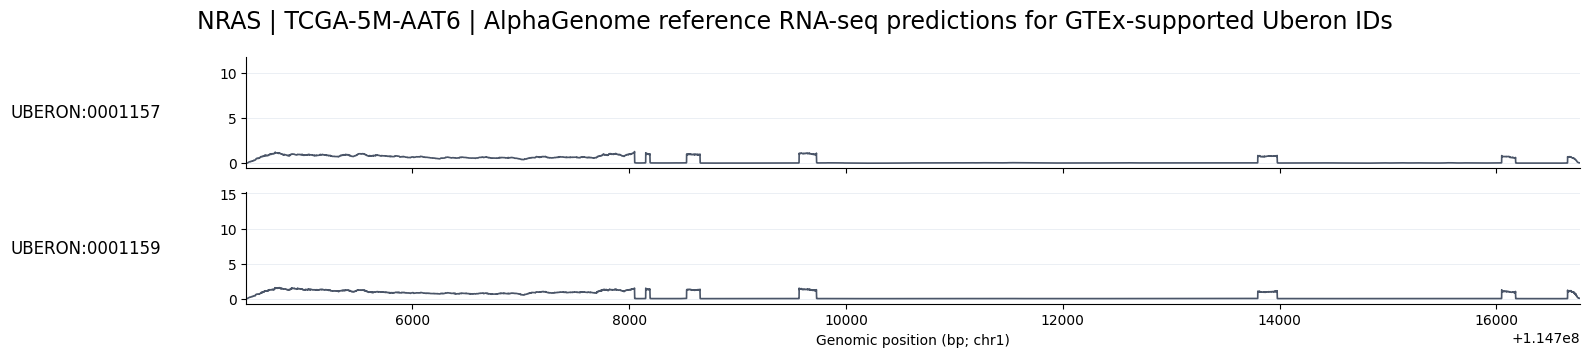

In [3]:
import textwrap

# Set True to preview AlphaGenome reference predictions for Uberon IDs with observed GTEx coverage.
SHOW_REFERENCE_TRACKS = True
REFERENCE_PREVIEW_LENGTH = dna_client.SEQUENCE_LENGTH_1MB
gtex_metadata = pd.read_csv(PROJECT_ROOT / 'metadata' / 'alphagenome_metadata.csv', dtype=str).fillna('')
GTEX_UBERON_IDS = set(gtex_metadata.loc[gtex_metadata['output_type'].eq('OutputType.RNA_SEQ') & gtex_metadata['data_source'].eq('gtex'), 'ontology_curie'])
GTEX_SELECTED_TRACKS = SELECTED_TRACKS.loc[SELECTED_TRACKS['ontology_curie'].isin(GTEX_UBERON_IDS)].copy()

if SHOW_REFERENCE_TRACKS:
    row = GENE_COORDINATES.loc[GENE]
    center = (int(row['start']) - 1 + int(row['end'])) // 2
    interval_start = max(0, center - REFERENCE_PREVIEW_LENGTH // 2)
    chromosome = str(row['chr'])
    preview_interval = genome.Interval(chromosome=chromosome if chromosome.startswith('chr') else f'chr{chromosome}', start=interval_start, end=interval_start + REFERENCE_PREVIEW_LENGTH)
    preview_key = hashlib.sha1(GTEX_SELECTED_TRACKS.to_csv(index=False).encode()).hexdigest()[:12]
    preview_cache = CACHE_DIR / CANCER_TYPE / f'{PATIENT_ID}_{GENE}_{preview_key}_{REFERENCE_PREVIEW_LENGTH}_gtex_uberon_reference_tracks_v1.npz'
    if preview_cache.exists():
        cached = np.load(preview_cache, allow_pickle=True)
        preview_names, preview_values, preview_resolution = cached['names'], cached['values'], int(cached['resolution'])
    else:
        api_key = os.environ.get('ALPHAGENOME_API_KEY') or API_KEY_FILE.read_text().strip()
        client = dna_client.create(api_key=api_key)
        sequence = Fasta(str(REFERENCE_FASTA), as_raw=True, sequence_always_upper=True)[preview_interval.chromosome][preview_interval.start:preview_interval.end]
        prediction = client.predict_sequence(sequence, organism=Organism.HOMO_SAPIENS, requested_outputs=[dna_output.OutputType.RNA_SEQ], ontology_terms=None, interval=preview_interval)
        track_data = prediction.get(dna_output.OutputType.RNA_SEQ)
        keys = set(zip(GTEX_SELECTED_TRACKS['track_name'].astype(str), GTEX_SELECTED_TRACKS['strand'].astype(str)))
        indices = np.flatnonzero([key in keys for key in zip(track_data.metadata['name'].astype(str), track_data.metadata['strand'].fillna('.').astype(str))])
        selected_metadata = track_data.metadata.iloc[indices].reset_index(drop=True)
        preview_values = np.asarray(track_data.select_tracks_by_index(indices).values, dtype=float)
        if preview_values.ndim == 1:
            preview_values = preview_values[None, :]
        elif preview_values.shape[0] != len(indices) and preview_values.shape[1] == len(indices):
            preview_values = preview_values.T
        preview_names, aggregated = [], []
        for uberon_id, rows in GTEX_SELECTED_TRACKS.groupby('ontology_curie'):
            group_keys = set(zip(rows['track_name'].astype(str), rows['strand'].astype(str)))
            group_indices = np.flatnonzero([key in group_keys for key in zip(selected_metadata['name'].astype(str), selected_metadata['strand'].fillna('.').astype(str))])
            units = []
            for _, name_indices in selected_metadata.iloc[group_indices].groupby('name').groups.items():
                name_indices = np.asarray(list(name_indices), dtype=int)
                strands = selected_metadata.loc[name_indices, 'strand'].fillna('.').astype(str).to_numpy()
                units.extend(preview_values[index] for index in name_indices[strands == '.'])
                plus, minus = name_indices[strands == '+'], name_indices[strands == '-']
                if len(plus) == 1 and len(minus) == 1:
                    units.append(preview_values[plus[0]] + preview_values[minus[0]])
            if units:
                preview_names.append(uberon_id)
                aggregated.append(np.mean(units, axis=0))
        preview_values = np.asarray(aggregated)
        preview_resolution = int(track_data.resolution)
        preview_cache.parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(preview_cache, names=np.asarray(preview_names), values=preview_values, resolution=preview_resolution)
    x = preview_interval.start + np.arange(preview_values.shape[-1]) * preview_resolution
    fig, axes = plt.subplots(len(preview_names), 1, figsize=(16, max(2.2, 1.8 * len(preview_names))), sharex=True, squeeze=False)
    for axis, name, values in zip(axes[:, 0], preview_names, preview_values):
        axis.plot(x, values, color='#4a5568', linewidth=1.2)
        axis.set_ylabel(textwrap.fill(name, width=15), rotation=0, ha='right', va='center', fontsize=12, labelpad=42)
        axis.spines[['right', 'top']].set_visible(False)
        axis.grid(axis='y', color='#e2e8f0', linewidth=.7, alpha=.7)
        axis.set_xlim(max(preview_interval.start, int(row['start']) - 1), min(preview_interval.end, int(row['end'])))
    axes[-1, 0].set_xlabel(f'Genomic position (bp; {preview_interval.chromosome})')
    fig.suptitle(f'{GENE} | {PATIENT_ID} | AlphaGenome reference RNA-seq predictions for GTEx-supported Uberon IDs', fontsize=17)
    fig.tight_layout()
    plt.show()

In [4]:
# Fetch observed GTEx/recount3 BigWig coverage for matching Uberon terms.
from urllib.request import urlretrieve

N_GTEX_SAMPLES_PER_TISSUE = 3
RECOUNT3_URL = 'https://data.idies.jhu.edu/recount3/data/human/data_sources/gtex'
RECOUNT3_BIGWIG_URL = 'https://recount-opendata.s3.amazonaws.com/recount3/release/human/data_sources/gtex'
gtex_metadata = pd.read_csv(PROJECT_ROOT / 'metadata' / 'alphagenome_metadata.csv', dtype=str).fillna('')
selected_uberon_ids = set(SELECTED_TRACKS['ontology_curie'])
GTEX_TRACKS = gtex_metadata.loc[
    gtex_metadata['output_type'].eq('OutputType.RNA_SEQ')
    & gtex_metadata['data_source'].eq('gtex')
    & gtex_metadata['ontology_curie'].isin(selected_uberon_ids),
    ['name', 'ontology_curie', 'biosample_name'],
].drop_duplicates().sort_values(['ontology_curie', 'name']).reset_index(drop=True)
GTEX_TRACKS['project'] = GTEX_TRACKS['name'].str.extract(r'gtex (.+) polyA plus RNA-seq')[0].str.lower()
recount3_tissues = pd.read_csv(PROJECT_ROOT / 'metadata' / 'borzoi_targets_human.txt', sep='\t', dtype=str)['description'].dropna().str.extract(r'^RNA:(.+)$')[0].dropna().unique()
def recount3_project(gtex_tissue):
    tokens = set(gtex_tissue.split('_'))
    return max(recount3_tissues, key=lambda tissue: (len(tokens & set(tissue.split('_'))), -len(tissue)))
GTEX_TRACKS['recount_project'] = GTEX_TRACKS['project'].map(recount3_project).str.upper()
GTEX_TRACKS = GTEX_TRACKS.sort_values('recount_project').drop_duplicates('recount_project').reset_index(drop=True)

gtex_row = GENE_COORDINATES.loc[GENE]
gtex_chromosome = str(gtex_row['chr']) if str(gtex_row['chr']).startswith('chr') else f"chr{gtex_row['chr']}"
gtex_start, gtex_end = int(gtex_row['start']) - 1, int(gtex_row['end'])
gtex_positions = np.linspace(gtex_start, gtex_end, 400, endpoint=False, dtype=int)
gtex_values = np.empty((0, len(gtex_positions)))
gtex_names = np.array([], dtype=str)

if GTEX_TRACKS.empty:
    print('No GTEx RNA-seq tissues match the selected Uberon terms.')
else:
    gtex_key = hashlib.sha1(';'.join(GTEX_TRACKS['recount_project']).encode()).hexdigest()[:12]
    gtex_cache = CACHE_DIR / f'{GENE}_{gtex_key}_{N_GTEX_SAMPLES_PER_TISSUE}_gtex_observed_coverage_v1.npz'
    if gtex_cache.exists():
        cached = np.load(gtex_cache, allow_pickle=True)
        gtex_names, gtex_values, gtex_positions = cached['names'], cached['values'], cached['positions']
    else:
        coverage, labels = [], []
        for track in GTEX_TRACKS.itertuples(index=False):
            project = track.recount_project
            metadata_cache = CACHE_DIR / f'gtex_{project}_metadata.tsv.gz'
            if not metadata_cache.exists() or metadata_cache.stat().st_size == 0:
                metadata_url = f'{RECOUNT3_URL}/metadata/{project[-2:]}/{project}/gtex.gtex.{project}.MD.gz'
                urlretrieve(metadata_url, metadata_cache)
            sample_metadata = pd.read_csv(metadata_cache, sep='\t', compression='gzip', dtype=str)
            sample_coverage = []
            for sample in sample_metadata.sort_values('external_id').head(N_GTEX_SAMPLES_PER_TISSUE).itertuples(index=False):
                sample_id = sample.external_id
                sample_prefix = sample_id.rsplit('.', 1)[0]
                bigwig_url = f'{RECOUNT3_BIGWIG_URL}/base_sums/{project[-2:]}/{project}/{sample_prefix[-2:]}/gtex.base_sums.{project}_{sample_id}.ALL.bw'
                with pyBigWig.open(bigwig_url) as bigwig:
                    sample_coverage.append(np.asarray(bigwig.stats(gtex_chromosome, gtex_start, gtex_end, nBins=len(gtex_positions)), dtype=float))
            coverage.append(np.nanmean(sample_coverage, axis=0))
            labels.append(f'{track.biosample_name} (GTEx, n={min(N_GTEX_SAMPLES_PER_TISSUE, len(sample_metadata))})')
        gtex_names, gtex_values = np.asarray(labels), np.asarray(coverage)
        np.savez_compressed(gtex_cache, names=gtex_names, values=gtex_values, positions=gtex_positions)
    print(f'Fetched observed GTEx/recount3 coverage for {len(gtex_names)} Uberon-matched tissues.')
GTEX_TRACKS

Fetched observed GTEx/recount3 coverage for 1 Uberon-matched tissues.


,name,ontology_curie,biosample_name,project,recount_project
0,UBERON:0001157 gtex Colon_Transverse polyA plu...,UBERON:0001157,transverse colon,colon_transverse,COLON


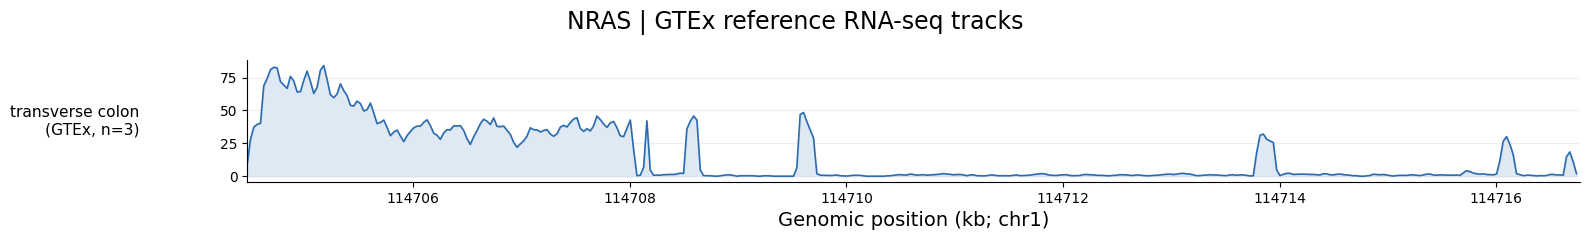

In [5]:
# Plot GTEx reference signals across the gene span.
if not GTEX_TRACKS.empty and len(gtex_values):
    fig, axes = plt.subplots(len(gtex_names), 1, figsize=(16, max(2.4, 1.9 * len(gtex_names))), sharex=True, squeeze=False)
    for axis, name, values in zip(axes[:, 0], gtex_names, gtex_values):
        axis.plot(gtex_positions, values, color='#2b6cb0', linewidth=1.2)
        axis.fill_between(gtex_positions, values, color='#2b6cb0', alpha=.15)
        axis.set_ylabel(textwrap.fill(name, width=18), rotation=0, ha='right', va='center', fontsize=PLOT_FONT_SIZE * .8, labelpad=58)
        axis.spines[['right', 'top']].set_visible(False)
        axis.grid(axis='y', color='#e2e8f0', linewidth=.7, alpha=.7)
        axis.set_xlim(gtex_start, gtex_end)
    axes[-1, 0].set_xlabel(f'Genomic position (kb; {gtex_chromosome})', fontsize=PLOT_FONT_SIZE)
    axes[-1, 0].xaxis.set_major_formatter(KB_FORMATTER)
    fig.suptitle(f'{GENE} | GTEx reference RNA-seq tracks', fontsize=PLOT_TITLE_SIZE)
    fig.tight_layout()
    plt.show()

In [6]:
def interval_for_gene(gene):
    row = GENE_COORDINATES.loc[gene]
    center = (int(row['start']) - 1 + int(row['end'])) // 2
    start = max(0, center - SEQUENCE_LENGTH // 2)
    chrom = str(row['chr'])
    return genome.Interval(chromosome=chrom if chrom.startswith('chr') else f'chr{chrom}', start=start, end=start + SEQUENCE_LENGTH)


def parse_variant(mutation):
    chrom, coordinates, reference, alternate = str(mutation).split(':')
    return genome.Variant(chromosome=chrom if chrom.startswith('chr') else f'chr{chrom}', position=int(coordinates.split('-')[0]), reference_bases=reference.replace('-', ''), alternate_bases=alternate.replace('-', ''), name=str(mutation))


def window_variants(interval):
    variants = pd.read_csv(VARIANT_DIR / f'{CANCER_TYPE}_variants.tsv', sep='\t', dtype=str, usecols=['bcr_patient_barcode', 'mutation'])
    candidates = [parse_variant(mutation) for mutation in variants.loc[variants['bcr_patient_barcode'].eq(PATIENT_ID), 'mutation'].dropna().drop_duplicates().sort_values()]
    return [variant for variant in candidates if variant.chromosome == interval.chromosome and interval.start <= variant.position - 1 < interval.end]


def apply_variants(sequence, interval, variants):
    edits = sorted((variant.position - 1 - interval.start, variant.reference_bases, variant.alternate_bases) for variant in variants)
    pieces, cursor = [], 0
    for start, reference, alternate in edits:
        end = start + len(reference)
        if reference and sequence[start:end].upper() != reference.upper():
            raise ValueError(f'Reference mismatch at {interval.chromosome}:{interval.start + start + 1}')
        pieces.extend([sequence[cursor:start], alternate])
        cursor = end
    pieces.append(sequence[cursor:])
    return (''.join(pieces) + 'N' * len(sequence))[:len(sequence)]


def non_overlapping_variants(variants):
    accepted, conflicts, last_end = [], [], -1
    for variant in sorted(variants, key=lambda variant: (variant.position, variant.name)):
        start, end = variant.position - 1, variant.position - 1 + max(1, len(variant.reference_bases))
        if start < last_end:
            conflicts.append(variant)
        else:
            accepted.append(variant)
            last_end = end
    return accepted, conflicts


def track_keys(selected_tracks=SELECTED_TRACKS):
    return set(zip(selected_tracks['track_name'].astype(str), selected_tracks['strand'].astype(str)))


def aggregate_tracks(track_data, selected_tracks=SELECTED_TRACKS, cancer_type=CANCER_TYPE):
    metadata = track_data.metadata.reset_index(drop=True)
    selected = np.flatnonzero([key in track_keys(selected_tracks) for key in zip(metadata['name'].astype(str), metadata['strand'].fillna('.').astype(str))])
    if not len(selected):
        raise ValueError(f'No curated RNA-seq tracks are mapped for {cancer_type}')
    values = np.asarray(track_data.select_tracks_by_index(selected).values, dtype=float)
    if values.ndim == 1:
        values = values[None, :]
    elif values.shape[0] != len(selected) and values.shape[1] == len(selected):
        values = values.T
    selected_metadata = metadata.iloc[selected].reset_index(drop=True)
    total_units = []
    for _, indices in selected_metadata.groupby('name').groups.items():
        indices = np.asarray(list(indices), dtype=int)
        strands = selected_metadata.loc[indices, 'strand'].fillna('.').astype(str).to_numpy()
        if np.any(strands == '.'):
            total_units.extend(values[index] for index in indices[strands == '.'])
        plus, minus = indices[strands == '+'], indices[strands == '-']
        if len(plus) == 1 and len(minus) == 1:
            total_units.append(values[plus[0]] + values[minus[0]])
    if not total_units:
        raise ValueError('No matched +/- or unstranded RNA-seq tracks are available')
    return np.mean(total_units, axis=0)


interval = interval_for_gene(GENE)
variants = window_variants(interval)
if not variants:
    raise ValueError(f'No patient variants overlap the prediction window for {PATIENT_ID} / {GENE}')
applied_variants, conflicting_variants = non_overlapping_variants(variants)
cache_key = hashlib.sha1(';'.join(variant.name for variant in applied_variants).encode()).hexdigest()[:12]
cache_path = CACHE_DIR / CANCER_TYPE / f'{PATIENT_ID}_{GENE}_{cache_key}_all_variants_v4_matched_total_tracks.npz'
if cache_path.exists():
    cached = np.load(cache_path)
    reference, alternate, resolution = cached['reference'], cached['alternate'], int(cached['resolution'])
else:
    api_key = os.environ.get('ALPHAGENOME_API_KEY') or API_KEY_FILE.read_text().strip()
    client = dna_client.create(api_key=api_key)
    reference_sequence = Fasta(str(REFERENCE_FASTA), as_raw=True, sequence_always_upper=True)[interval.chromosome][interval.start:interval.end]
    alternate_sequence = apply_variants(reference_sequence, interval, applied_variants)
    reference_prediction = client.predict_sequence(reference_sequence, organism=Organism.HOMO_SAPIENS, requested_outputs=[dna_output.OutputType.RNA_SEQ], ontology_terms=None, interval=interval)
    alternate_prediction = client.predict_sequence(alternate_sequence, organism=Organism.HOMO_SAPIENS, requested_outputs=[dna_output.OutputType.RNA_SEQ], ontology_terms=None, interval=interval)
    reference_tracks = reference_prediction.get(dna_output.OutputType.RNA_SEQ)
    alternate_tracks = alternate_prediction.get(dna_output.OutputType.RNA_SEQ)
    reference, alternate, resolution = aggregate_tracks(reference_tracks), aggregate_tracks(alternate_tracks), int(reference_tracks.resolution)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(cache_path, reference=reference, alternate=alternate, resolution=resolution)

sample_sheet = pd.read_csv(SAMPLE_SHEET, sep='\t', dtype=str)
available = {path.parent.name for path in BIGWIG_DIR.rglob('*.bw')}
file_id = sample_sheet.loc[sample_sheet['Case ID'].eq(PATIENT_ID) & sample_sheet['Project ID'].eq(f'TCGA-{CANCER_TYPE}') & sample_sheet['File ID'].isin(available), 'File ID'].iloc[0]
bigwig_path = next((BIGWIG_DIR / file_id).glob('*.bw'))
with pyBigWig.open(str(bigwig_path)) as bigwig:
    observed = np.log1p(np.asarray(bigwig.stats(interval.chromosome, interval.start, interval.end, nBins=len(reference)), dtype=float))
positions = interval.start + np.arange(len(reference)) * resolution
print(f'{len(variants)} patient variants overlap the prediction window:')
print('\n'.join(variant.name for variant in variants))
print(f'Applied {len(applied_variants)} non-overlapping variants; cache: {cache_path.name}')
if conflicting_variants:
    print(f'Excluded {len(conflicting_variants)} overlapping variant records:')
    print('\n'.join(variant.name for variant in conflicting_variants))


10 patient variants overlap the prediction window:
1:114704499-114704499:A:G
1:114705629-114705630:CT:C
1:114709433-114709434:TA:T
1:114711443-114711444:CA:C
1:114711613-114711619:AAAAAAC:A
1:114711615-114711619:AAAAC:A
1:114712349-114712350:AT:A
1:114714458-114714459:GT:G
1:114716249-114716249:T:C
1:114717311-114717311:A:AT
Applied 9 non-overlapping variants; cache: TCGA-5M-AAT6_NRAS_271264647053_all_variants_v4_matched_total_tracks.npz
Excluded 1 overlapping variant records:
1:114711615-114711619:AAAAC:A


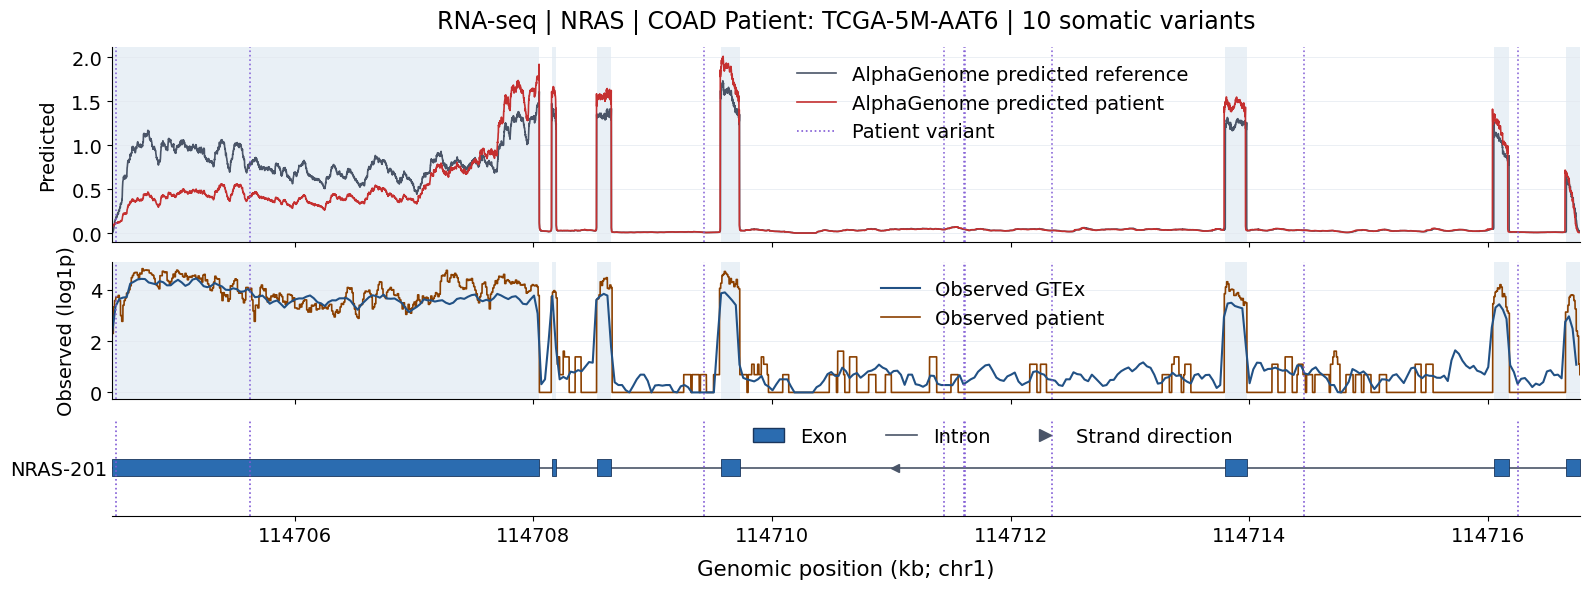

In [7]:
PLOT_FONT_SIZE = 14
PLOT_TITLE_SIZE = 17
KB_FORMATTER = FuncFormatter(lambda value, _: f'{value / 1_000:.0f}')

def attributes(text):
    return {key: value.strip().strip('"') for item in text.rstrip(';').split(';') if ' ' in item for key, value in [item.strip().split(' ', 1)]}

def transcripts(gene):
    models = {}
    with GTF_PATH.open() as handle:
        for line in handle:
            fields = line.rstrip().split('\t')
            if len(fields) != 9 or fields[2] != 'exon':
                continue
            info = attributes(fields[8])
            if info.get('gene_name') == gene:
                key = (info.get('transcript_id', ''), info.get('transcript_name', info.get('transcript_id', '')))
                models.setdefault(key, {'exons': [], 'strand': fields[6]})['exons'].append((int(fields[3]) - 1, int(fields[4])))
    return sorted(models.items(), key=lambda item: (-len(item[1]['exons']), item[0][1]))[:3]

gene_row = GENE_COORDINATES.loc[GENE]
plot_interval = genome.Interval(chromosome=interval.chromosome, start=max(interval.start, int(gene_row['start']) - 1), end=min(interval.end, int(gene_row['end'])))
mask = (positions >= plot_interval.start) & (positions < plot_interval.end)
variant_positions = [variant.position - 1 for variant in variants]
models = transcripts(GENE)
exon_spans = sorted({exon for _, model in models for exon in model['exons']})
transcript_height = max(1, .4 * len(models))
fig, axes = plt.subplots(3, 1, figsize=(16, 5 + transcript_height), sharex=True, height_ratios=[2, 1.4, transcript_height])
axes[0].plot(positions[mask], reference[mask], color='#4a5568', linewidth=1.2, label='AlphaGenome reference (strand-summed)')
axes[0].plot(positions[mask], alternate[mask], color='#c53030', linewidth=1.2, label='AlphaGenome alternate (strand-summed)')
axes[0].set_ylabel('Predicted', fontsize=PLOT_FONT_SIZE, labelpad=10)
axes[1].plot(positions[mask], observed[mask], color='#8b4000', linewidth=1.2, label='Observed')
# axes[1].fill_between(positions[mask], observed[mask], color='#2b6cb0', alpha=.25)
observed_handles = []
if 'gtex_values' in globals() and len(gtex_values):
    gtex_mask = (gtex_positions >= plot_interval.start) & (gtex_positions < plot_interval.end)
    mean_gtex = np.nanmean(gtex_values, axis=0)
    axes[1].plot(gtex_positions[gtex_mask], np.log1p(mean_gtex[gtex_mask]), color="#215185", linewidth=1.5)
    observed_handles.append(Line2D([0], [0], color='#215185', linewidth=1.5, label='Observed GTEx'))
observed_handles.append(Line2D([0], [0], color='#8b4000', linewidth=1.2, label='Observed patient'))
axes[0].legend(handles=[
    Line2D([0], [0], color='#4a5568', linewidth=1.2, label='AlphaGenome predicted reference'),
    Line2D([0], [0], color='#c53030', linewidth=1.2, label='AlphaGenome predicted patient'),
    Line2D([0], [0], color='#805ad5', linestyle=':', linewidth=1.2, label='Patient variant'),
], loc='upper center', bbox_to_anchor=(.6, 1), ncol=1, frameon=False, fontsize=PLOT_FONT_SIZE)
axes[1].legend(handles=observed_handles, loc='upper center', bbox_to_anchor=(.6, 1), ncol=1, frameon=False, fontsize=PLOT_FONT_SIZE)
axes[1].set_ylabel('Observed (log1p)', fontsize=PLOT_FONT_SIZE, labelpad=10)
for axis in axes[:2]:
    for start, end in exon_spans:
        axis.axvspan(start, end, color='#2b6cb0', alpha=.1, linewidth=0, zorder=0)
    for position in variant_positions:
        axis.axvline(position, color='#805ad5', linestyle=':', linewidth=1.2, alpha=.9, zorder=3, label='Patient variant' if axis is axes[0] else None)
    axis.spines[['right', 'top']].set_visible(False)
    axis.grid(axis='y', color='#e2e8f0', linewidth=.7, alpha=.7)
    axis.set_axisbelow(True)
    axis.tick_params(axis='both', labelsize=PLOT_FONT_SIZE)
for row, ((_, name), model) in enumerate(models):
    y, exons = len(models) - row - 1, model['exons']
    axes[2].hlines(y, min(start for start, _ in exons), max(end for _, end in exons), color='#4a5568', linewidth=1.2, zorder=1)
    for start, end in exons:
        axes[2].broken_barh([(start, end - start)], (y - .12, .24), facecolors='#2b6cb0', edgecolors='#1a365d', linewidth=.6, zorder=2)
    direction = '>' if model['strand'] == '+' else '<' if model['strand'] == '-' else '|'
    axes[2].plot(np.mean([start for start, _ in exons]), y, marker=direction, color='#4a5568', markersize=6, linestyle='None', zorder=3)
for position in variant_positions:
    axes[2].axvline(position, color='#805ad5', linestyle=':', linewidth=1.2, zorder=4)
axes[2].set_xlim(plot_interval.start, plot_interval.end)
axes[2].set_yticks(range(len(models)))
axes[2].set_yticklabels([name for (_, name), _ in reversed(models)], fontsize=PLOT_FONT_SIZE)
axes[2].set_ylim(-.7, max(.7, len(models) - .3))
axes[2].spines[['right', 'top', 'left']].set_visible(False)
axes[2].tick_params(axis='y', length=0)
axes[2].tick_params(axis='x', labelsize=PLOT_FONT_SIZE)
axes[2].set_xlabel(f'Genomic position (kb; {interval.chromosome})', fontsize=PLOT_FONT_SIZE * 1.1, labelpad=10)
axes[2].xaxis.set_major_formatter(KB_FORMATTER)
axes[2].set_ylabel('', fontsize=PLOT_FONT_SIZE, labelpad=10)
figure_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor='#2b6cb0', edgecolor='#1a365d', label='Exon'),
    Line2D([0], [0], color='#4a5568', linewidth=1.2, label='Intron'),
    Line2D([0], [0], marker='>', color='#4a5568', linestyle='None', markersize=8, label='Strand direction')
]
axes[0].set_title(f'RNA-seq | {GENE} | {CANCER_TYPE} Patient: {PATIENT_ID} | {len(variants)} somatic variants', fontsize=PLOT_TITLE_SIZE, pad=14)
fig.subplots_adjust(hspace=.02)
axes[2].legend(handles=figure_handles, loc='upper center', bbox_to_anchor=(.6, 1.1), ncol=3, frameon=False, fontsize=PLOT_FONT_SIZE, handlelength=1.6, labelspacing=.2)
plt.tight_layout()
plt.savefig(PLOT_DIR / f'{PATIENT_ID}_{GENE}_rnaseq_predicted_observed_tracks.png', dpi=300, bbox_inches='tight')

## ISM analysis

Predicted reference-versus-patient RNA-seq tracks across the full gene. Generate attribution logos for every gene-overlapping patient variant and each available dense AlphaGenome modality.

The selections below are independent of the observed-track analysis above.

In [13]:
from scipy.stats import wilcoxon
import pickle
from matplotlib.font_manager import FontProperties
from matplotlib.patches import PathPatch
from matplotlib.textpath import TextPath
from matplotlib.transforms import Affine2D
from alphagenome.interpretation import ism
from alphagenome.models import variant_scorers

In [14]:
ISM_PATIENT_ID = 'TCGA-02-0026'
ISM_GENE = 'PTEN'
ISM_CANCER_TYPE = json.loads((PROJECT_ROOT / 'data' / 'tcga_patient_cancer_map.json').read_text())[ISM_PATIENT_ID]
ISM_SEQUENCE_LENGTH = dna_client.SEQUENCE_LENGTH_1MB
ISM_SELECTED_TRACKS = select_rnaseq_tracks(ISM_CANCER_TYPE, SELECTED_TRACK_NAMES)

ISM_ANALYSIS_WINDOW = 64
ISM_PREDICTION_LENGTH = 131_072
ISM_MAX_TRACKS_PER_MODALITY = 4
ISM_FIGURE_DIR = PLOT_DIR / 'ism_attribution_logos'
ISM_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f'{ISM_PATIENT_ID} | {ISM_CANCER_TYPE} | {ISM_GENE} | {len(ISM_SELECTED_TRACKS)} RNA-seq tracks')

TCGA-02-0026 | GBM | PTEN | 15 RNA-seq tracks


In [9]:
def ism_patient_gene_variants(gene):
    records = pd.read_csv(VARIANT_DIR / f'{ISM_CANCER_TYPE}_variants.tsv', sep='\t', dtype=str, usecols=['bcr_patient_barcode', 'gene_name', 'mutation'])
    row = GENE_COORDINATES.loc[gene]
    chromosome = str(row['chr']) if str(row['chr']).startswith('chr') else f"chr{row['chr']}"
    mutations = records.loc[records['bcr_patient_barcode'].eq(ISM_PATIENT_ID) & records['gene_name'].eq(gene), 'mutation'].dropna().drop_duplicates().sort_values()
    return [variant for variant in map(parse_variant, mutations) if variant.chromosome == chromosome and int(row['start']) - 1 <= variant.position - 1 < int(row['end'])]

def ism_interval_for_gene(gene, variants):
    row = GENE_COORDINATES.loc[gene]
    if variants:
        start = min(variant.position - 1 for variant in variants)
        end = max(variant.position - 1 + max(1, len(variant.reference_bases)) for variant in variants)
        if end - start > ISM_SEQUENCE_LENGTH:
            raise ValueError(f'Patient variants for {gene} span more than {ISM_SEQUENCE_LENGTH:,} bp')
        center = (start + end) // 2
    else:
        center = (int(row['start']) - 1 + int(row['end'])) // 2
    start = max(0, center - ISM_SEQUENCE_LENGTH // 2)
    chromosome = str(row['chr'])
    return genome.Interval(chromosome=chromosome if chromosome.startswith('chr') else f'chr{chromosome}', start=start, end=start + ISM_SEQUENCE_LENGTH)

ism_variants = ism_patient_gene_variants(ISM_GENE)
ism_interval = ism_interval_for_gene(ISM_GENE, ism_variants)
ism_variants = [variant for variant in ism_variants if ism_interval.start <= variant.position - 1 < ism_interval.end]
if not ism_variants:
    raise ValueError(f'No gene variants found for {ISM_PATIENT_ID} / {ISM_GENE}')
ism_applied_variants, ism_conflicting_variants = non_overlapping_variants(ism_variants)
ism_cache_key = hashlib.sha1(';'.join(variant.name for variant in ism_applied_variants).encode()).hexdigest()[:12]
ism_tracks_key = hashlib.sha1(ISM_SELECTED_TRACKS.to_csv(index=False).encode()).hexdigest()[:12]
ism_cache_path = CACHE_DIR / ISM_CANCER_TYPE / f'{ISM_PATIENT_ID}_{ISM_GENE}_{ism_cache_key}_{ism_tracks_key}_{ISM_SEQUENCE_LENGTH}_all_variants_v6_full_gene.npz'
if ism_cache_path.exists():
    cached = np.load(ism_cache_path)
    ism_reference, ism_alternate, ism_resolution = cached['reference'], cached['alternate'], int(cached['resolution'])
else:
    api_key = os.environ.get('ALPHAGENOME_API_KEY') or API_KEY_FILE.read_text().strip()
    client = dna_client.create(api_key=api_key)
    reference_sequence = Fasta(str(REFERENCE_FASTA), as_raw=True, sequence_always_upper=True)[ism_interval.chromosome][ism_interval.start:ism_interval.end]
    alternate_sequence = apply_variants(reference_sequence, ism_interval, ism_applied_variants)
    requested_outputs = [dna_output.OutputType.RNA_SEQ]
    reference_prediction = client.predict_sequence(reference_sequence, organism=Organism.HOMO_SAPIENS, requested_outputs=requested_outputs, ontology_terms=None, interval=ism_interval)
    alternate_prediction = client.predict_sequence(alternate_sequence, organism=Organism.HOMO_SAPIENS, requested_outputs=requested_outputs, ontology_terms=None, interval=ism_interval)
    reference_tracks = reference_prediction.get(dna_output.OutputType.RNA_SEQ)
    alternate_tracks = alternate_prediction.get(dna_output.OutputType.RNA_SEQ)
    ism_reference, ism_alternate, ism_resolution = aggregate_tracks(reference_tracks, ISM_SELECTED_TRACKS, ISM_CANCER_TYPE), aggregate_tracks(alternate_tracks, ISM_SELECTED_TRACKS, ISM_CANCER_TYPE), int(reference_tracks.resolution)
    ism_cache_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(ism_cache_path, reference=ism_reference, alternate=ism_alternate, resolution=ism_resolution)

ism_positions = ism_interval.start + np.arange(len(ism_reference)) * ism_resolution
print(f'Applied {len(ism_applied_variants)} variants; cache: {ism_cache_path.name}')

Applied 2 variants; cache: TCGA-02-0026_PTEN_32e5018107b8_37aad94beeff_1048576_all_variants_v6_full_gene.npz


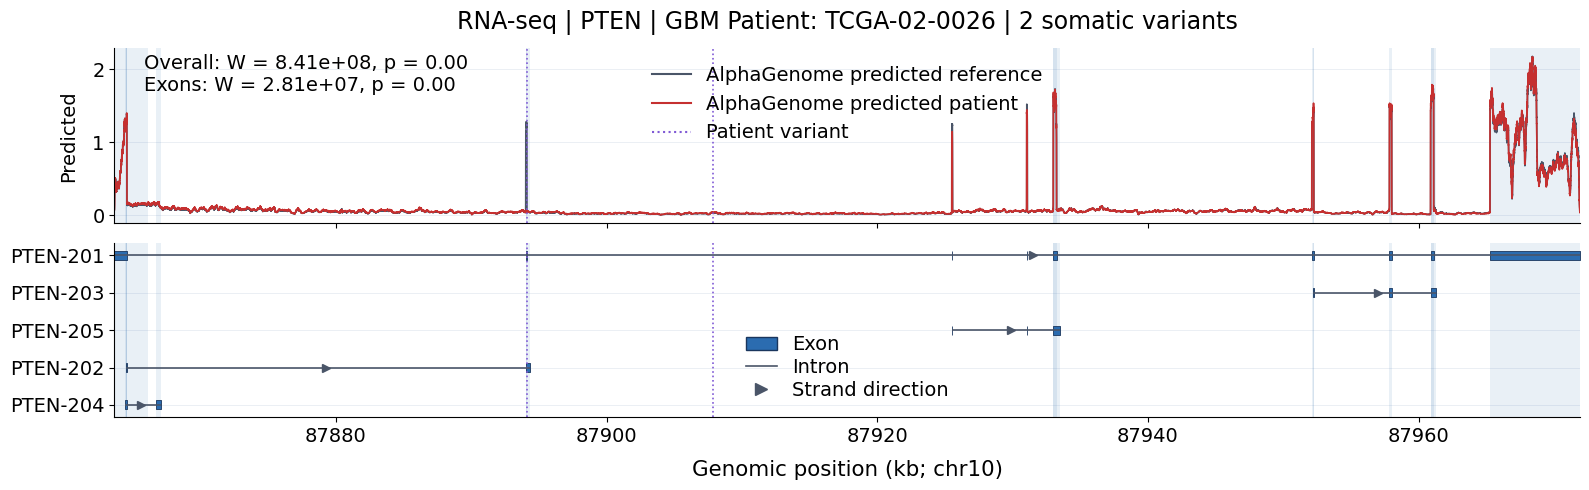

In [ ]:
def ism_transcripts(gene, limit=None):
    models = {}
    with GTF_PATH.open() as handle:
        for line in handle:
            fields = line.rstrip().split('\t')
            if len(fields) != 9 or fields[2] != 'exon':
                continue
            info = attributes(fields[8])
            if info.get('gene_name') == gene:
                key = (info.get('transcript_id', ''), info.get('transcript_name', info.get('transcript_id', '')))
                models.setdefault(key, {'exons': [], 'strand': fields[6]})['exons'].append((int(fields[3]) - 1, int(fields[4])))
    ordered = sorted(models.items(), key=lambda item: (-len(item[1]['exons']), item[0][1]))
    return ordered if limit is None else ordered[:limit]

ism_gene_row = GENE_COORDINATES.loc[ISM_GENE]
ism_plot_interval = genome.Interval(chromosome=ism_interval.chromosome, start=max(ism_interval.start, int(ism_gene_row['start']) - 1), end=min(ism_interval.end, int(ism_gene_row['end'])))
ism_mask = (ism_positions >= ism_plot_interval.start) & (ism_positions < ism_plot_interval.end)
ism_models = ism_transcripts(ISM_GENE, limit=5)
ism_exons = sorted({exon for _, model in ism_transcripts(ISM_GENE) for exon in model['exons']})
ism_exon_mask = np.zeros(len(ism_positions), dtype=bool)
for start, end in ism_exons:
    ism_exon_mask |= (ism_positions >= start) & (ism_positions < end)

def ism_wilcoxon(label, region_mask):
    valid = ism_mask & region_mask & np.isfinite(ism_reference) & np.isfinite(ism_alternate)
    if not valid.any() or np.allclose(ism_reference[valid], ism_alternate[valid]):
        return f'{label}: W = 0, p = 1, n = {valid.sum()}'
    result = wilcoxon(ism_alternate[valid], ism_reference[valid])
    return f'{label}: W = {result.statistic:.2e}, p = {result.pvalue:.2f}'

ism_label = '\n'.join([ism_wilcoxon('Overall', np.ones(len(ism_positions), dtype=bool)), ism_wilcoxon('Exons', ism_exon_mask)])
height = max(1, .4 * len(ism_models))
fig, axes = plt.subplots(2, 1, figsize=(16, 3 + height), sharex=True, height_ratios=[2, height])
axes[0].plot(ism_positions[ism_mask], ism_reference[ism_mask], color='#4a5568', linewidth=1.2, label='AlphaGenome predicted reference')
axes[0].plot(ism_positions[ism_mask], ism_alternate[ism_mask], color='#c53030', linewidth=1.2, label='AlphaGenome predicted patient')
axes[0].text(.02, .97, ism_label, transform=axes[0].transAxes, ha='left', va='top', fontsize=PLOT_FONT_SIZE)
axes[0].set_ylabel('Predicted', fontsize=PLOT_FONT_SIZE, labelpad=10)
for axis in axes:
    for start, end in ism_exons:
        axis.axvspan(start, end, color='#2b6cb0', alpha=.1, linewidth=0)
    for variant in ism_variants:
        axis.axvline(variant.position - 1, color='#805ad5', linestyle=':', linewidth=1.2)
    axis.spines[['right', 'top']].set_visible(False)
    axis.grid(axis='y', color='#e2e8f0', linewidth=.7, alpha=.7)
    axis.set_axisbelow(True)
    axis.tick_params(axis='both', labelsize=PLOT_FONT_SIZE)

for row, ((_, name), model) in enumerate(ism_models):
    y, exons = len(ism_models) - row - 1, model['exons']
    axes[1].hlines(y, min(start for start, _ in exons), max(end for _, end in exons), color='#4a5568', linewidth=1.2)
    for start, end in exons:
        axes[1].broken_barh([(start, end - start)], (y - .12, .24), facecolors='#2b6cb0', edgecolors='#1a365d', linewidth=.6)
    direction = '>' if model['strand'] == '+' else '<' if model['strand'] == '-' else '|'
    axes[1].plot(np.mean([start for start, _ in exons]), y, marker=direction, color='#4a5568', markersize=6, linestyle='None')
axes[1].set_xlim(ism_plot_interval.start, ism_plot_interval.end)
axes[1].set_yticks(range(len(ism_models)))
axes[1].set_yticklabels([name for (_, name), _ in reversed(ism_models)], fontsize=PLOT_FONT_SIZE)
axes[1].set_xlabel(f'Genomic position (kb; {ism_interval.chromosome})', fontsize=PLOT_FONT_SIZE * 1.1, labelpad=10)
axes[1].xaxis.set_major_formatter(KB_FORMATTER)
annotation_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor='#2b6cb0', edgecolor='#1a365d', label='Exon'),
    Line2D([0], [0], color='#4a5568', linewidth=1.2, label='Intron'),
    Line2D([0], [0], marker='>', color='#4a5568', linestyle='None', markersize=8, label='Strand direction')
]
axes[1].legend(handles=annotation_handles, loc='lower center', ncol=1, frameon=False, fontsize=PLOT_FONT_SIZE, handlelength=1.6, labelspacing=.2)
axes[0].legend(handles=[Line2D([0], [0], color='#4a5568', label='AlphaGenome predicted reference'), Line2D([0], [0], color='#c53030', label='AlphaGenome predicted patient'), Line2D([0], [0], color='#805ad5', linestyle=':', label='Patient variant')], loc='upper center', frameon=False, fontsize=PLOT_FONT_SIZE)
axes[0].set_title(f'RNA-seq | {ISM_GENE} | {ISM_CANCER_TYPE} Patient: {ISM_PATIENT_ID} | {len(ism_variants)} somatic variants', fontsize=PLOT_TITLE_SIZE, pad=14)
plt.tight_layout()
plt.savefig(PLOT_DIR / f'{ISM_PATIENT_ID}_{ISM_GENE}_ism_rnaseq_predicted_tracks.png', dpi=300, bbox_inches='tight')

100%|██████████| 7/7 [00:13<00:00,  1.91s/it]


/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_rnaseq_predicted_observed_plots/ism_attribution_logos/TCGA-02-0026_PTEN_10_87894104-87894109_AGTAAG_A_RNA_SEQ_ism.png


100%|██████████| 7/7 [00:13<00:00,  1.92s/it]


/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_rnaseq_predicted_observed_plots/ism_attribution_logos/TCGA-02-0026_PTEN_10_87907839-87907843_CACTA_C_RNA_SEQ_ism.png


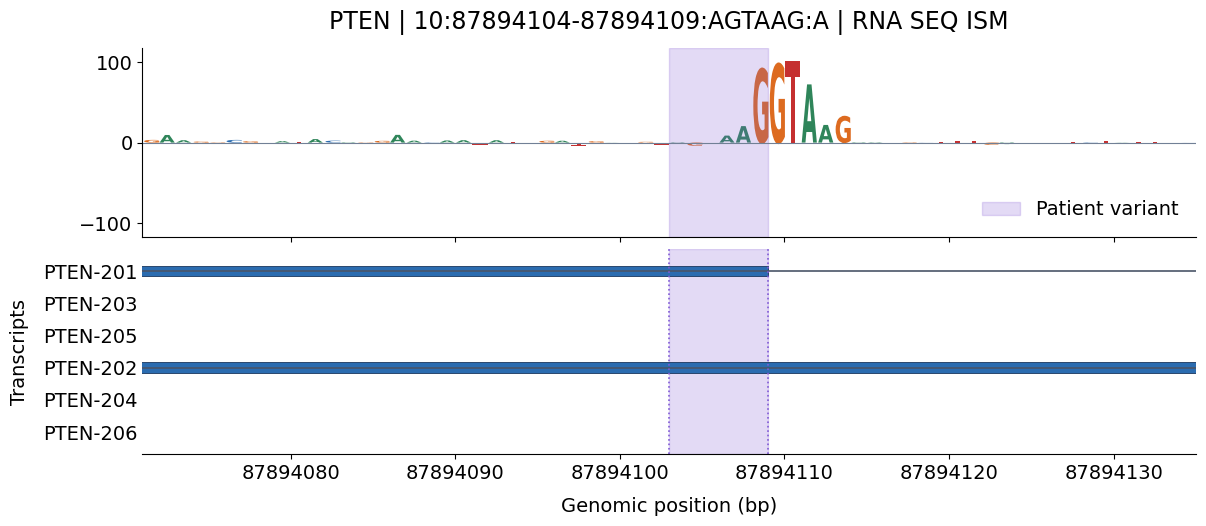

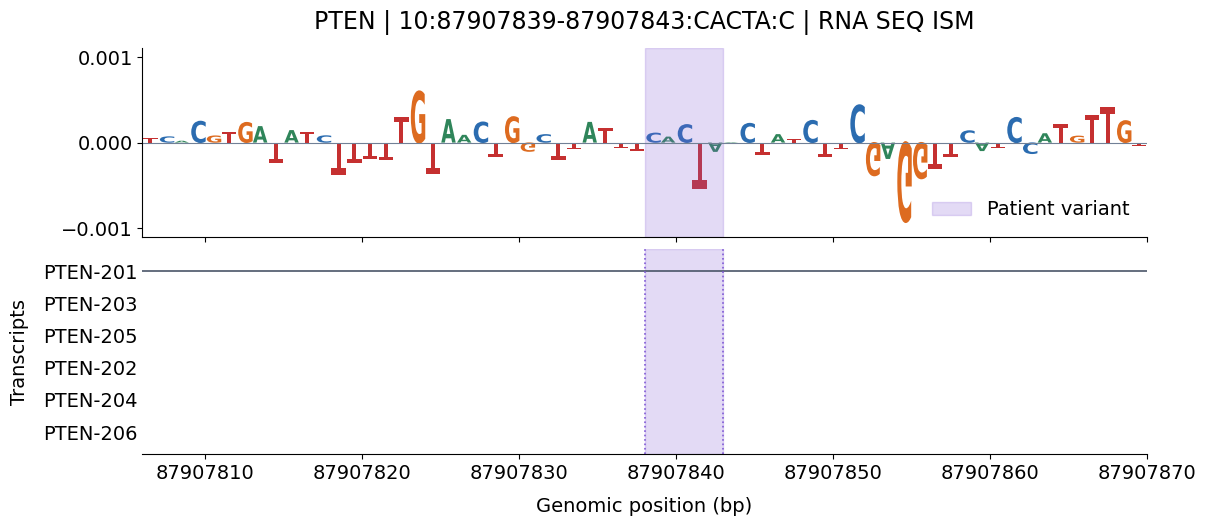

In [15]:
def ism_output_key(value):
    return str(value).rsplit('.', 1)[-1].upper()

def ism_choose_tracks(tracks):
    tracks = tracks.copy()
    tracks['output_key'] = tracks['output_type'].map(ism_output_key)
    tracks['strand'] = tracks['strand'].where(tracks['strand'].isin(['+', '-', '.']), '.')
    gene_strand = str(GENE_COORDINATES.loc[ISM_GENE, 'strand'])
    chosen = []
    for _, group in tracks.groupby('output_key', sort=True):
        preferred = group.loc[group['strand'].eq(gene_strand)]
        preferred = preferred if not preferred.empty else group.loc[group['strand'].eq('.')]
        chosen.append((preferred if not preferred.empty else group).drop_duplicates('track_name').head(ISM_MAX_TRACKS_PER_MODALITY))
    return pd.concat(chosen, ignore_index=True)

ISM_CURATED_TRACKS = ism_choose_tracks(track_mapping.loc[track_mapping['cancer_type'].eq(ISM_CANCER_TYPE)])
ISM_CURATED_TRACKS = ISM_CURATED_TRACKS.loc[ISM_CURATED_TRACKS['output_key'].eq('RNA_SEQ')].copy()
ISM_MODALITIES = sorted(ISM_CURATED_TRACKS['output_key'].unique())
ISM_SCORERS = [variant_scorers.CenterMaskScorer(getattr(dna_output.OutputType, modality), 501, variant_scorers.AggregationType.DIFF_SUM) for modality in ISM_MODALITIES]

ism_gene_row = GENE_COORDINATES.loc[ISM_GENE]
ism_gene_start = int(ism_gene_row['start']) - 1
ism_gene_end = int(ism_gene_row['end'])
ism_gene_center = (ism_gene_start + ism_gene_end) // 2
ism_prediction_start = max(0, ism_gene_center - ISM_PREDICTION_LENGTH // 2)
ISM_PREDICTION_INTERVAL = genome.Interval(ism_interval.chromosome, ism_prediction_start, ism_prediction_start + ISM_PREDICTION_LENGTH)
ISM_LOGO_TRACKS_KEY = hashlib.sha1(ISM_CURATED_TRACKS.to_csv(index=False).encode()).hexdigest()[:12]

def ism_track_score(outputs, scorer_index, modality):
    score = outputs[scorer_index]
    names = set(ISM_CURATED_TRACKS.loc[ISM_CURATED_TRACKS['output_key'].eq(modality), 'track_name'])
    indices = np.flatnonzero(score.var['name'].astype(str).isin(names).to_numpy())
    if not len(indices):
        raise ValueError(f'No curated {modality} track was returned for ISM.')
    return np.ravel(np.asarray(score.X))[int(indices[0])]

def ism_add_logo_base(ax, base, position, attribution):
    colors = {'A': '#2f855a', 'C': '#2b6cb0', 'G': '#dd6b20', 'T': '#c53030'}
    if not np.isfinite(attribution) or attribution == 0 or base not in colors:
        return
    path = TextPath((0, 0), base, size=1, prop=FontProperties(weight='bold'))
    bounds = path.get_extents()
    transform = Affine2D().scale(.92 / bounds.width, np.sign(attribution) * abs(attribution) / bounds.height).translate(position + .04, 0) + ax.transData
    ax.add_patch(PathPatch(path, transform=transform, color=colors[base], linewidth=0))

ism_transcript_models = ism_transcripts(ISM_GENE)

def ism_plot_transcripts(ax, positions):
    for row, ((_, name), model) in enumerate(ism_transcript_models):
        y, exons = len(ism_transcript_models) - row - 1, model['exons']
        ax.hlines(y, min(start for start, _ in exons), max(end for _, end in exons), color='#4a5568', linewidth=1.2)
        for start, end in exons:
            ax.broken_barh([(start, end - start)], (y - .16, .32), facecolors='#2b6cb0', edgecolors='#1a365d', linewidth=.6)
        direction = '>' if model['strand'] == '+' else '<' if model['strand'] == '-' else '|'
        ax.plot(np.mean([start for start, _ in exons]), y, marker=direction, color='#4a5568', markersize=6, linestyle='None')
    for position in positions:
        ax.axvline(position, color='#805ad5', linestyle=':', linewidth=1.2)
    ax.set_yticks(range(len(ism_transcript_models)))
    ax.set_yticklabels([name for (_, name), _ in reversed(ism_transcript_models)], fontsize=PLOT_FONT_SIZE * .8)
    ax.set_ylim(-.7, max(.7, len(ism_transcript_models) - .3))
    ax.spines[['right', 'top', 'left']].set_visible(False)
    ax.tick_params(axis='y', length=0)

for patient_variant in ism_variants:
    variant_start = patient_variant.position - 1
    variant_end = variant_start + max(1, len(patient_variant.reference_bases))
    analysis_start = max(ISM_PREDICTION_INTERVAL.start, variant_start - ISM_ANALYSIS_WINDOW // 2)
    analysis_start = min(analysis_start, ISM_PREDICTION_INTERVAL.end - ISM_ANALYSIS_WINDOW)
    analysis_interval = genome.Interval(ISM_PREDICTION_INTERVAL.chromosome, analysis_start, analysis_start + ISM_ANALYSIS_WINDOW)
    cache_path = CACHE_DIR / ISM_CANCER_TYPE / f'{ISM_PATIENT_ID}_{ISM_GENE}_{patient_variant.name.replace(":", "_")}_{ISM_LOGO_TRACKS_KEY}_ism_{ISM_ANALYSIS_WINDOW}bp_v1.pkl'
    if cache_path.exists():
        with cache_path.open('rb') as handle:
            ism_results = pickle.load(handle)
    else:
        api_key = os.environ.get('ALPHAGENOME_API_KEY') or API_KEY_FILE.read_text().strip()
        client = dna_client.create(api_key=api_key)
        ism_results = client.score_ism_variants(interval=ISM_PREDICTION_INTERVAL, ism_interval=analysis_interval, variant_scorers=ISM_SCORERS, organism=Organism.HOMO_SAPIENS, progress_bar=True, max_workers=1)
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        with cache_path.open('wb') as handle:
            pickle.dump(ism_results, handle)
    reference_bases = Fasta(str(REFERENCE_FASTA), as_raw=True, sequence_always_upper=True)[analysis_interval.chromosome][analysis_interval.start:analysis_interval.end]
    for scorer_index, modality in enumerate(ISM_MODALITIES):
        try:
            scores = [ism_track_score(outputs, scorer_index, modality) for outputs in ism_results]
        except ValueError as error:
            print(error)
            continue
        variants = [outputs[scorer_index].uns['variant'] for outputs in ism_results]
        matrix = ism.ism_matrix(scores, variants, interval=analysis_interval)
        base_index = {base: index for index, base in enumerate('ACGT')}
        attributions = np.array([matrix[position, base_index.get(base, 0)] if base in base_index else 0 for position, base in enumerate(reference_bases)])
        vmax = np.nanmax(np.abs(attributions)) or 1
        height = max(1.4, .4 * len(ism_transcript_models))
        fig, axes = plt.subplots(2, 1, figsize=(12, 2.8 + height), sharex=True, height_ratios=[2.2, height])
        for offset, (base, attribution) in enumerate(zip(reference_bases, attributions)):
            ism_add_logo_base(axes[0], base, analysis_interval.start + offset, attribution)
        axes[0].axhline(0, color='#718096', linewidth=.8)
        axes[0].axvspan(variant_start, variant_end, color='#805ad5', alpha=.22, label='Patient variant')
        axes[0].set_xlim(analysis_interval.start, analysis_interval.end)
        axes[0].set_ylim(-vmax * 1.15, vmax * 1.15)
        axes[0].set_title(f'{ISM_GENE} | {patient_variant.name} | {modality.replace("_", " ")} ISM', fontsize=PLOT_TITLE_SIZE, pad=14)
        axes[0].tick_params(axis='both', labelsize=PLOT_FONT_SIZE, labelbottom=False)
        axes[0].spines[['right', 'top']].set_visible(False)
        axes[0].legend(frameon=False, loc='lower right', fontsize=PLOT_FONT_SIZE)
        ism_plot_transcripts(axes[1], [variant_start, variant_end])
        axes[1].axvspan(variant_start, variant_end, color='#805ad5', alpha=.22, zorder=0)
        axes[1].set_xlim(analysis_interval.start, analysis_interval.end)
        axes[1].set_xlabel('Genomic position (bp)', fontsize=PLOT_FONT_SIZE, labelpad=10)
        axes[1].set_ylabel('Transcripts', fontsize=PLOT_FONT_SIZE, labelpad=10)
        axes[1].ticklabel_format(axis='x', style='plain', useOffset=False)
        axes[1].tick_params(axis='both', labelsize=PLOT_FONT_SIZE)
        plt.tight_layout(pad=.5)
        figure_path = ISM_FIGURE_DIR / f'{ISM_PATIENT_ID}_{ISM_GENE}_{patient_variant.name.replace(":", "_")}_{modality}_ism.png'
        plt.savefig(figure_path, dpi=300, bbox_inches='tight')
        print(figure_path)